In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [29]:
# Read label file
labels_path = Path("../labels/test_balanced.csv").resolve()
labels_df = pd.read_csv(labels_path)
labels_df.shape

(804, 3)

In [11]:
# Get distribution of labels
labels_df['count'].value_counts().sort_index()

count
0    60777
1     5263
2      550
3       89
4       17
5        1
6        4
7        1
Name: count, dtype: int64

In [12]:
# Treat images with more than 4 micronuclei as 4
labels_df.loc[labels_df['count'] > 4, 'count'] = 4
labels_df['count'].value_counts().sort_index()

count
0    60777
1     5263
2      550
3       89
4       23
Name: count, dtype: int64

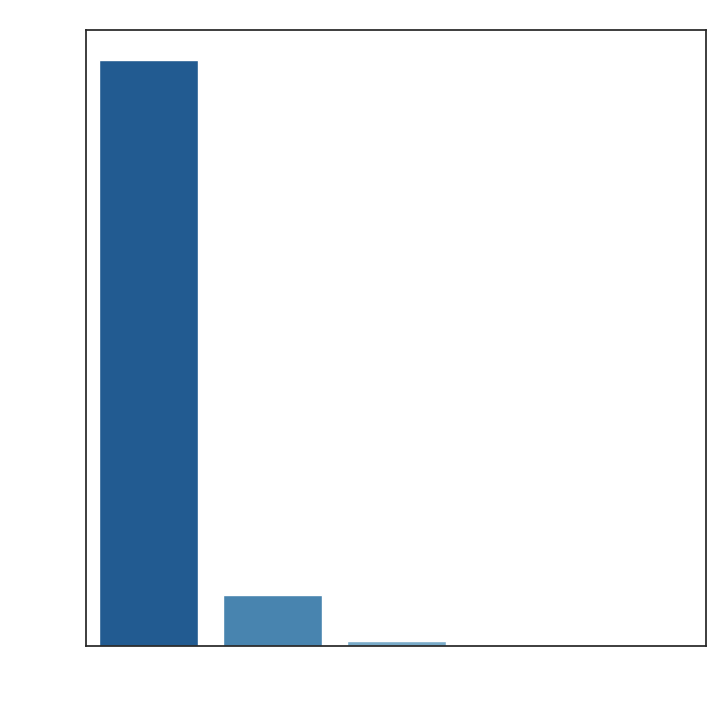

In [13]:
sns.set(rc={'ytick.labelcolor':'white','xtick.labelcolor':'white', 'text.color':'white'}) # Set color of labels to white
sns.set_style("white")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.countplot(data=labels_df, x='count', palette="Blues_r")
ax.set_title("Micronuclei distribution", color="white")
ax.set_xlabel("# micronuclei", color="white")
ax.set_ylabel("Count", color="white")
fig.savefig(Path("../figures/micronuclei_distribution.pdf"), transparent=True, dpi=300)
fig.savefig(Path("../figures/micronuclei_distribution.png"), transparent=True, dpi=300)

In [14]:
# mpl.rcParams.keys()

In [15]:
# Get distribution of images with at least one micronuclei
labels_df['label'].value_counts().sort_index()

label
0    60777
1     5925
Name: count, dtype: int64

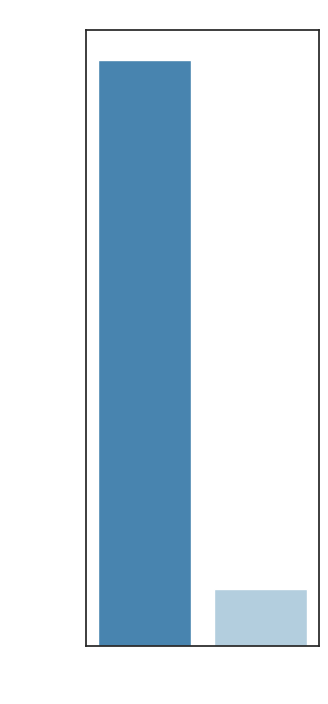

In [16]:
sns.set(rc={'ytick.labelcolor':'white','xtick.labelcolor':'white', 'text.color':'white'}) # Set color of labels to white
sns.set_style("white")
fig, ax = plt.subplots(1, 1, figsize=(3, 8))
sns.countplot(data=labels_df, x='label', palette="Blues_r")
ax.set_title("Micronuclei Presence/Absence", color="white")
ax.set_xlabel("CIN", color="white")
ax.set_ylabel("Count", color="white")
fig.savefig(Path("../figures/cin_distribution.pdf"), transparent=True, dpi=300)
fig.savefig(Path("../figures/cin_distribution.png"), transparent=True, dpi=300)

In [17]:
# Stratify labels by presence of micronuclei
has_mn = labels_df[labels_df["label"]==1]
no_mn = labels_df[labels_df["label"]==0]
no_mn = no_mn.sample(n=len(has_mn), random_state=42)
print(len(has_mn))
print(len(no_mn))
balanced = pd.concat([has_mn, no_mn])

5925
5925


In [18]:
balanced

,image,count,label
11,s02c1_13.png,1,1
12,s02c1_14.png,1,1
32,s02c1_34.png,1,1
39,s02c1_41.png,1,1
44,s02c1_46.png,1,1
...,...,...,...
63327,s43c1_4531.png,0,0
5129,s04c1_3351.png,0,0
31160,s15c1_516.png,0,0
41971,s27c1_1993.png,0,0


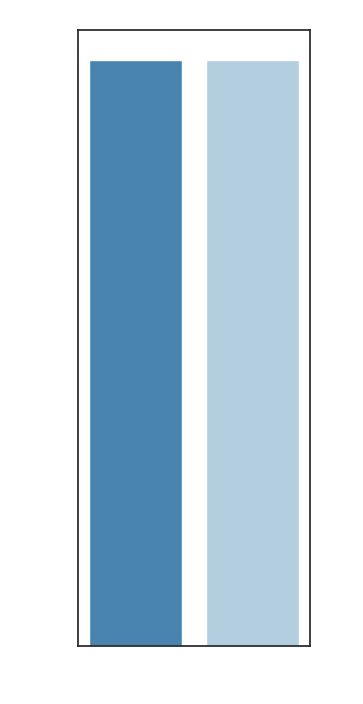

In [19]:
sns.set(rc={'ytick.labelcolor':'white','xtick.labelcolor':'white', 'text.color':'white'}) # Set color of labels to white
sns.set_style("white")
fig, ax = plt.subplots(1, 1, figsize=(3, 8))
sns.countplot(data=balanced, x='label', palette="Blues_r")
ax.set_title("Micronuclei Presence/Absence  (Balanced)", color="white")
ax.set_xlabel("CIN", color="white")
ax.set_ylabel("Count", color="white")
fig.savefig(Path("../figures/cin_distribution_balanced.pdf"), transparent=True, dpi=300)
fig.savefig(Path("../figures/cin_distribution_balanced.png"), transparent=True, dpi=300)

In [20]:
balanced['count'].value_counts().sort_index()

count
0    5925
1    5263
2     550
3      89
4      23
Name: count, dtype: int64

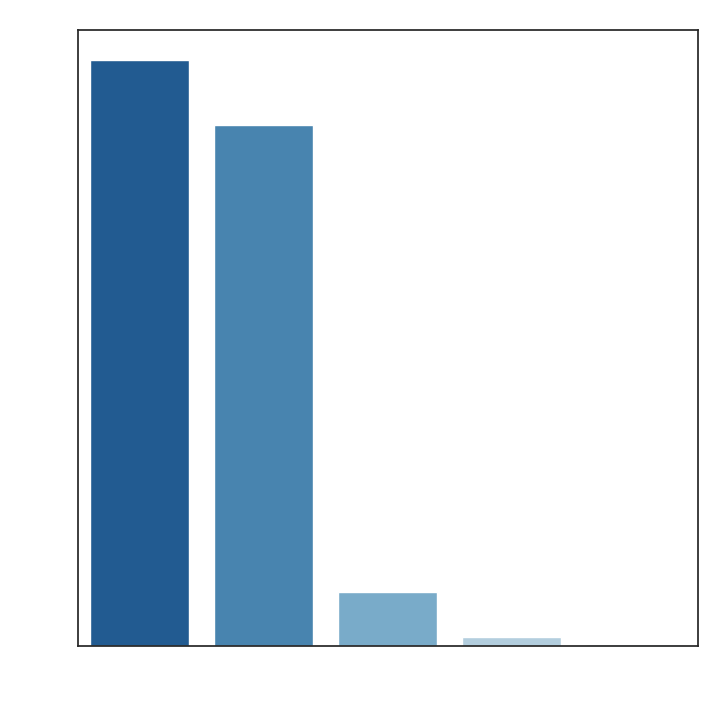

In [21]:
sns.set(rc={'ytick.labelcolor':'white','xtick.labelcolor':'white', 'text.color':'white'}) # Set color of labels to white
sns.set_style("white")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
sns.countplot(data=balanced, x='count', palette="Blues_r")
ax.set_title("Micronuclei distribution (Balanced)", color="white")
ax.set_xlabel("# micronuclei", color="white")
ax.set_ylabel("Count", color="white")
fig.savefig(Path("../figures/micronuclei_distribution_balanced.pdf"), transparent=True, dpi=300)
fig.savefig(Path("../figures/micronuclei_distribution_balanced.png"), transparent=True, dpi=300)

In [14]:
# balanced.to_csv(Path(f"/Users/miguelibarra/PycharmProjects/micronuclei_labeling_tool/out/{labels_path.stem}_balanced.csv").resolve(), index=False)